### **Task Overview**

I will be integrating the [WeightWatcher framework](https://github.com/CalculatedContent/WeightWatcher) with the [Informer (2020) model](https://github.com/zhouhaoyi/Informer2020). The goal is to extract the model weights and compute their singular value spectra for each encoder layer using WeightWatcher.

### **My Approach:**

1.  **Environment Setup**: Clone the Informer2020 repository and install required dependencies, including WeightWatcher.
2.  **Model Inspection**: Understand the Informer model architecture to identify and access the encoder layers and their weights.
3.  **Weight Extraction & Analysis**: Implement code to iterate through the encoder layers, extract their weight matrices, and apply WeightWatcher to compute the singular value spectra.
4.  **Visualization & Reporting**: Present the results of the singular value spectra for each encoder layer.

Let's start by setting up the environment.

In [1]:
# Clone the Informer2020 repository
!git clone https://github.com/zhouhaoyi/Informer2020.git

# Install WeightWatcher and other necessary libraries
!pip install weightwatcher torch numpy pandas

Cloning into 'Informer2020'...
remote: Enumerating objects: 590, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 590 (delta 6), reused 3 (delta 3), pack-reused 578 (from 2)
Receiving objects: 100% (590/590), 6.49 MiB | 10.77 MiB/s, done.
Resolving deltas: 100% (336/336), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.7/83.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 15.0 MB/s eta 0:00:00


In [17]:
%cd Informer2020

!ls

[Errno 2] No such file or directory: 'Informer2020'
/content/Informer2020
data		 exp	  main_informer.py  README.md	      utils
Dockerfile	 img	  Makefile	    requirements.txt
environment.yml  LICENSE  models	    scripts


In [4]:
# List contents of the models directory
!ls models

attn.py  decoder.py  embed.py  encoder.py  __init__.py	model.py


#### **Instantiate Informer Model**
Define a placeholder `Args` class to mimic command-line arguments that the original Informer repository uses. This allows me to configure and create an instance of the `Informer` model which is essential for inspecting its layers and extracting weights.

In [6]:
import torch
from models.model import Informer

# These parameters are based on common Informer configurations and are placeholders
# We will adjust them as needed once we understand the model's __init__ method better
class Args:
    def __init__(self):
        self.model = 'informer'
        self.data = 'ETTh1'
        self.root_path = './data/ETTh1/'
        self.data_path = 'ETTh1.csv'
        self.features = 'M'
        self.seq_len = 96
        self.label_len = 48
        self.pred_len = 24
        self.enc_in = 7 # Example: number of features in encoder input
        self.dec_in = 7 # Example: number of features in decoder input
        self.c_out = 7 # Example: number of features in output
        self.d_model = 512
        self.embed = 'h'
        self.freq = 'h'
        self.dropout = 0.05
        self.attn = 'prob'
        self.factor = 5
        self.n_heads = 8
        self.d_ff = 2048
        self.activation = 'gelu'
        self.e_layers = 2 # Number of encoder layers
        self.d_layers = 1 # Number of decoder layers
        self.do_predict = False
        self.out_len = 24 # This was a missing argument

args = Args()

# Instantiate the Informer model with explicit arguments
model = Informer(
    args.enc_in, args.dec_in, args.c_out, args.seq_len,
    args.label_len, args.out_len, args.factor, args.d_model,
    args.n_heads, args.e_layers, args.d_layers, args.d_ff,
    args.dropout, args.attn, args.embed, args.freq,
    args.activation, args.do_predict
).float()

print("Informer model instantiated successfully.")
print(model)

Informer model instantiated successfully.
Informer(
  (enc_embedding): DataEmbedding(
    (value_embedding): TokenEmbedding(
      (tokenConv): Conv1d(7, 512, kernel_size=(3,), stride=(1,), padding=(1,), padding_mode=circular)
    )
    (position_embedding): PositionalEmbedding()
    (temporal_embedding): TemporalEmbedding(
      (hour_embed): Embedding(24, 512)
      (weekday_embed): Embedding(7, 512)
      (day_embed): Embedding(32, 512)
      (month_embed): Embedding(13, 512)
    )
    (dropout): Dropout(p=0.05, inplace=False)
  )
  (dec_embedding): DataEmbedding(
    (value_embedding): TokenEmbedding(
      (tokenConv): Conv1d(7, 512, kernel_size=(3,), stride=(1,), padding=(1,), padding_mode=circular)
    )
    (position_embedding): PositionalEmbedding()
    (temporal_embedding): TemporalEmbedding(
      (hour_embed): Embedding(24, 512)
      (weekday_embed): Embedding(7, 512)
      (day_embed): Embedding(32, 512)
      (month_embed): Embedding(13, 512)
    )
    (dropout): Dropout

#### **Initial WeightWatcher Analysis**
Integrating the WeightWatcher framework and initialize a `WeightWatcher` object with instantiated Informer model and then run its `analyze()` method to get an initial analysis of the model's layers. Also check if the `svs` (singular value spectra) column is populated, as earlier attempts indicated it might not be by default in this WeightWatcher version.

In [20]:
import weightwatcher as ww
import matplotlib.pyplot as plt

print(f"WeightWatcher version: {ww.__version__}")

# Initialize WeightWatcher with the Informer model
ww_watcher = ww.WeightWatcher(model=model)

details_df = ww_watcher.analyze()

print("\n--- details_df content ---")
print("details_df head:")
print(details_df.head())
print("\nChecking for 'svs' column and its content:")
if 'svs' in details_df.columns:
    for index, row in details_df.iterrows():
        name = row['name']
        svs = row.get('svs')
        if svs is not None and len(svs) > 0:
            print(f"  Found SVs for: {name}")
        elif svs is not None:
            print(f"  Found empty SVs for: {name}")
        else:
            print(f"  No 'svs' entry for: {name}")
else:
    print("  'svs' column not found in details_df.")

WeightWatcher version: 0.7.7
SMALL N PL FIT
SMALL N PL FIT

--- details_df content ---
details_df head:
   layer_id         name         D   M    N          Q     alpha  \
0         6   hour_embed  0.143207  24  512  21.333333  6.751687   
1         8    day_embed  0.167600  32  512  16.000000  4.758025   
2         9  month_embed  0.170743  13  512  39.384615  7.886600   
3        16   hour_embed  0.179988  24  512  21.333333  4.559651   
4        18    day_embed  0.169583  32  512  16.000000  4.181418   

   alpha_weighted   entropy  has_esd  ...     sigma spectral_norm  \
0       19.409597  0.993212     True  ...  1.660369    749.509583   
1       13.743564  0.991670     True  ...  0.801214    773.573669   
2       22.069131  0.996156     True  ...  2.295533    628.503235   
3       12.941002  0.993576     True  ...  0.795962    688.900391   
4       12.076352  0.992064     True  ...  0.649404    772.858276   

   stable_rank   status     sv_max     sv_min        warning  weak_rank_

#### **Manual SVD Extraction**
Since the `WeightWatcher.analyze()` method did not directly provide singular value spectra (`svs`) in the `details_df`, proceed with manual extraction. This code iterates through all named modules in the model, identifies `Linear`, `Conv1d`, and `Embedding` layers, extracts their weight matrices, reshapes `Conv1d` weights to 2D if necessary, and then computes the Singular Value Decomposition (SVD) using `numpy.linalg.svd`. The extracted singular values are stored and then visualized for a sample of the layers.

Manually extracting weights and computing Singular Value Spectra for all layers...
  Processing layer: enc_embedding.value_embedding.tokenConv (original shape: torch.Size([512, 7, 3]), SVD shape: (512, 21))
    Successfully extracted 21 singular values.
  Processing layer: enc_embedding.temporal_embedding.hour_embed (original shape: torch.Size([24, 512]), SVD shape: (24, 512))
    Successfully extracted 24 singular values.
  Processing layer: enc_embedding.temporal_embedding.weekday_embed (original shape: torch.Size([7, 512]), SVD shape: (7, 512))
    Successfully extracted 7 singular values.
  Processing layer: enc_embedding.temporal_embedding.day_embed (original shape: torch.Size([32, 512]), SVD shape: (32, 512))
    Successfully extracted 32 singular values.
  Processing layer: enc_embedding.temporal_embedding.month_embed (original shape: torch.Size([13, 512]), SVD shape: (13, 512))
    Successfully extracted 13 singular values.
  Processing layer: dec_embedding.value_embedding.toke

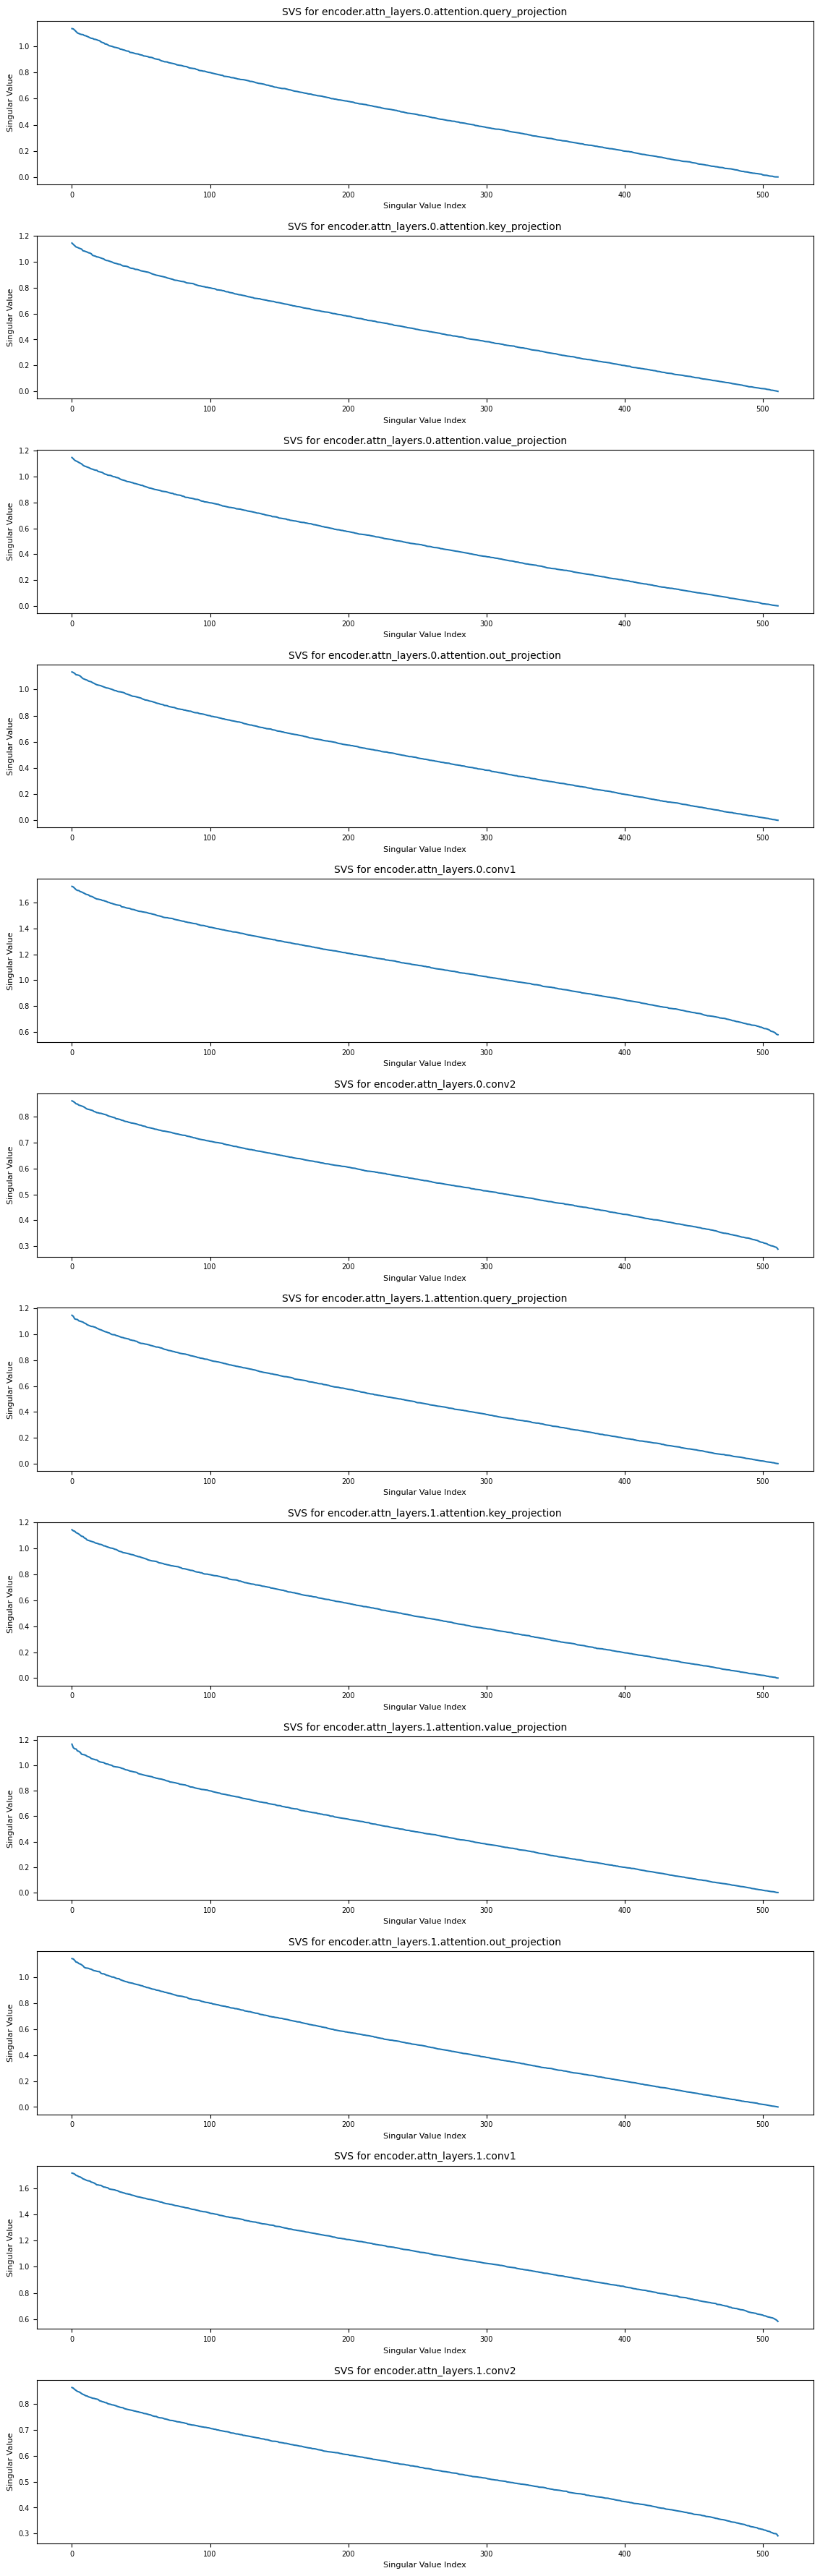


Summary of manually extracted singular value spectra (first 5 values for each of the first 10 layers):
  enc_embedding.value_embedding.tokenConv: [8.135582  8.095053  7.9591107 7.719497  7.6223006]...
  enc_embedding.temporal_embedding.hour_embed: [27.377039 26.872644 26.368927 25.83778  24.781214]...
  enc_embedding.temporal_embedding.weekday_embed: [24.328554 23.873085 23.213528 21.855135 21.082596]...
  enc_embedding.temporal_embedding.day_embed: [27.81325  27.515713 27.000765 26.67158  26.311655]...
  enc_embedding.temporal_embedding.month_embed: [25.07016  24.662775 24.342337 23.647442 23.267681]...
  dec_embedding.value_embedding.tokenConv: [8.381005  8.260502  8.040843  7.8208766 7.587139 ]...
  dec_embedding.temporal_embedding.hour_embed: [26.24723  25.920923 25.805948 25.41914  25.130138]...
  dec_embedding.temporal_embedding.weekday_embed: [24.683277 24.497734 23.5232   23.068794 22.138224]...
  dec_embedding.temporal_embedding.day_embed: [27.80056  27.19271  26.942892 26.47

In [19]:
import numpy as np
import torch.nn as nn

all_layers_svs_results = {}

print("Manually extracting weights and computing Singular Value Spectra for all layers...")

# Iterate through all named modules in the model
for name, module in model.named_modules():
    if isinstance(module, (nn.Linear, nn.Conv1d, nn.Embedding)) and hasattr(module, 'weight'):
        weight_matrix_torch = module.weight.data.cpu()
        weight_matrix_np = None

        if isinstance(module, nn.Conv1d):
            # Reshape 3D Conv1d weights to 2D (output_channels, input_channels * kernel_size)
            # Ensure the weight is treated as a single matrix for SVD
            weight_matrix_np = weight_matrix_torch.reshape(weight_matrix_torch.shape[0], -1).numpy()
        elif isinstance(module, (nn.Linear, nn.Embedding)):
            # Linear and Embedding layers already have 2D weights
            weight_matrix_np = weight_matrix_torch.numpy()

        if weight_matrix_np is not None and weight_matrix_np.size > 0:
            print(f"  Processing layer: {name} (original shape: {weight_matrix_torch.shape}, SVD shape: {weight_matrix_np.shape})")
            try:
                # Compute Singular Value Decomposition
                # full_matrices=False for economy SVD
                u, s, vh = np.linalg.svd(weight_matrix_np, full_matrices=False)
                all_layers_svs_results[name] = s
                print(f"    Successfully extracted {len(s)} singular values.")
            except np.linalg.LinAlgError as e:
                print(f"    SVD failed for {name}: {e}. Skipping this layer.")
            except Exception as e:
                print(f"    An unexpected error occurred for {name}: {e}. Skipping this layer.")
        else:
            print(f"  Skipping empty or non-applicable weight for layer: {name}")

print("\nFinished manual SVD extraction for all layers.")

if all_layers_svs_results:
    print("\nSample Visualization of Manually Extracted Singular Value Spectra (Top 12 layers):")

    # Sort results by number of singular values (descending) or alphabetically for consistency
    # Taking top 12 to avoid too many plots
    sorted_results = dict(sorted(all_layers_svs_results.items(), key=lambda item: len(item[1]), reverse=True))
    display_results = list(sorted_results.items())[:12] # Limit to top 12 for visualization

    num_plots = len(display_results)
    if num_plots > 0:
        # Adjust figsize dynamically
        fig, axes = plt.subplots(num_plots, 1, figsize=(12, 3 * num_plots))
        fig.tight_layout(pad=3.0)

        # Ensure axes is always iterable, even for a single plot
        if num_plots == 1:
            axes = [axes]

        for j, (name, svs) in enumerate(display_results):
            ax = axes[j]
            ax.plot(svs)
            ax.set_title(f'SVS for {name}', fontsize=10)
            ax.set_xlabel('Singular Value Index', fontsize=8)
            ax.set_ylabel('Singular Value', fontsize=8)
            ax.tick_params(axis='both', which='major', labelsize=7)
        plt.show()
    else:
        print("No singular value spectra results to display for visualization.")
else:
    print("No singular value spectra results to display.")

print("\nSummary of manually extracted singular value spectra (first 5 values for each of the first 10 layers):")
for i, (name, svs) in enumerate(all_layers_svs_results.items()):
    if i >= 10: # Print summary for first 10 layers
        break
    print(f"  {name}: {svs[:5]}...")

### **Analyzing Singular Value Distributions by Layer Type**

Now that we have extracted singular values for all relevant layers, let's categorize them by their type (Linear, Conv1d, Embedding) and visualize their distributions. This can reveal insights into the spectral properties of different types of transformations within the model.

Distribution of singular values across layer types:
             count       mean       std        min        25%        50%  \
Layer Type                                                                 
Conv1d      3626.0   0.868709  0.752037   0.246153   0.523297   0.716961   
Embedding    152.0  22.517269  2.509468  17.215496  20.581168  22.370457   
Linear      8199.0   0.490019  0.305282   0.000115   0.228443   0.467059   

                  75%        max  
Layer Type                        
Conv1d       1.047742   8.381005  
Embedding   24.380556  27.813250  
Linear       0.733038   1.165807  


/tmp/ipykernel_921/2758718418.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Layer Type')


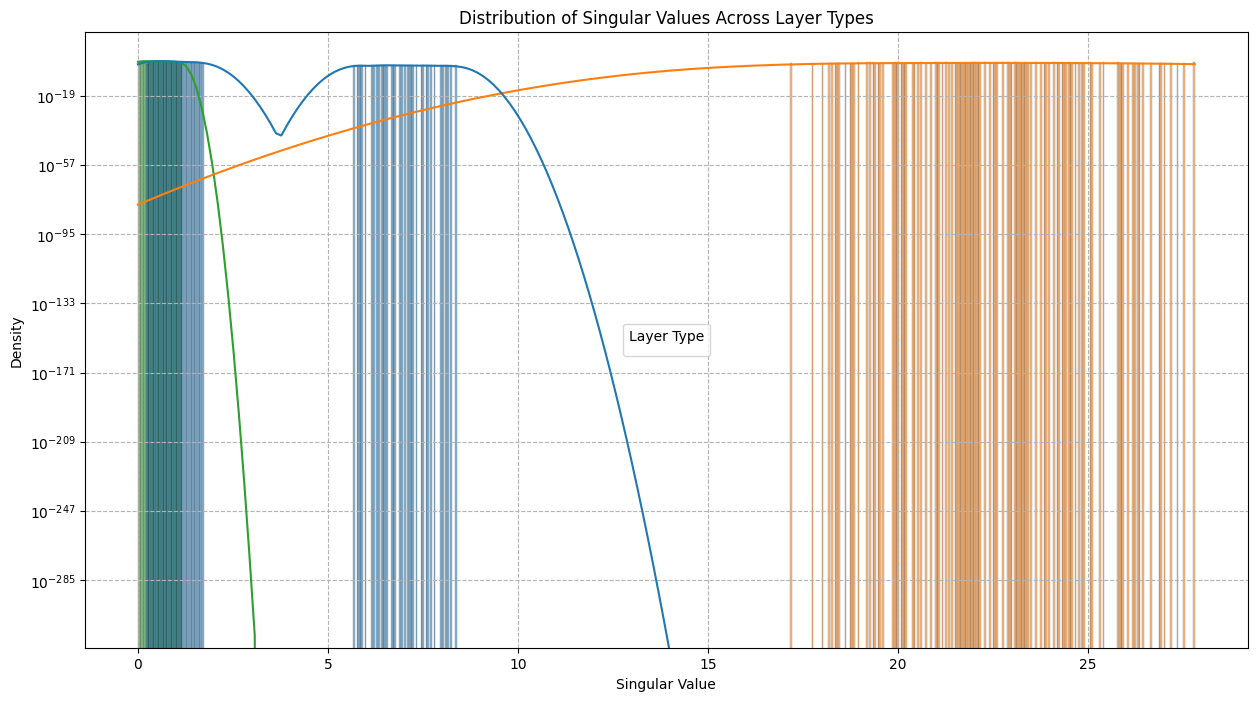

/tmp/ipykernel_921/2758718418.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sv_dist, x='Layer Type', y='Singular Value', palette='viridis')


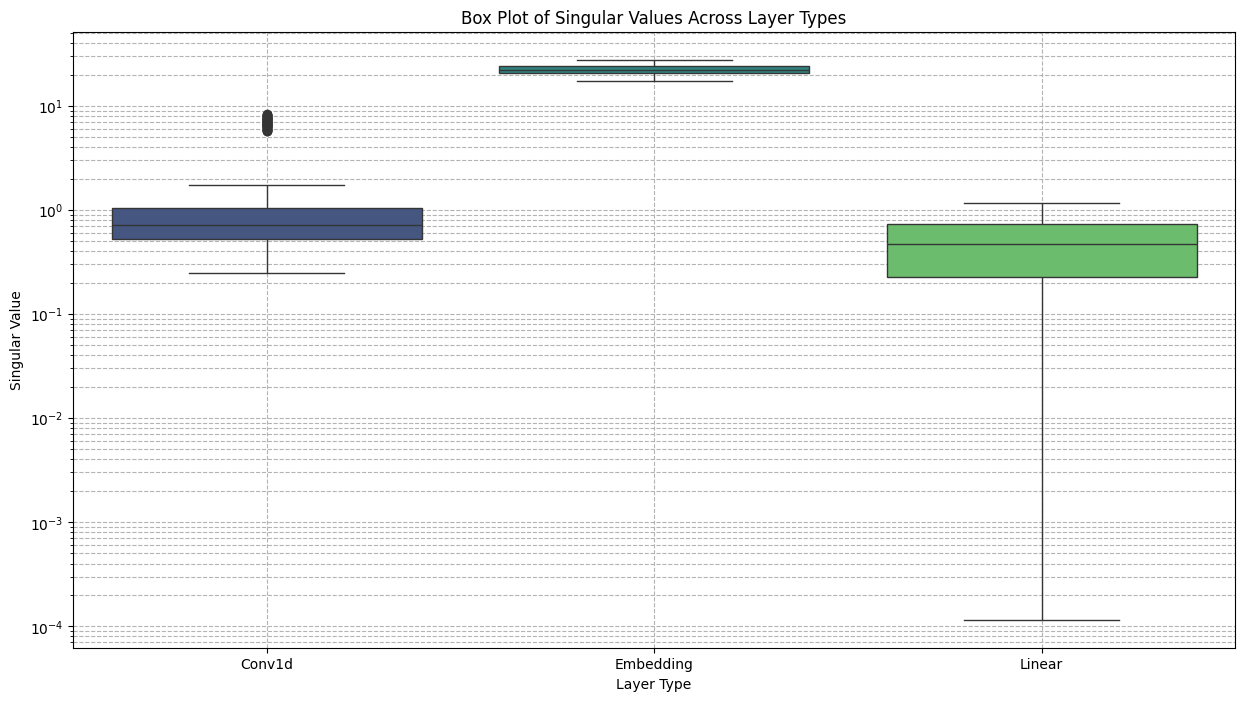

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Helper function to classify layer type based on name patterns
def classify_layer_type(name):
    if 'query_projection' in name or 'key_projection' in name or \
       'value_projection' in name or 'out_projection' in name or \
       'projection' in name and 'tokenConv' not in name: # Exclude tokenConv from Linear
        return 'Linear'
    elif 'conv' in name or 'Conv' in name: # Catches Conv1d layers like tokenConv, conv1, conv2
        return 'Conv1d'
    elif 'embed' in name or 'Embedding' in name:
        return 'Embedding'
    return 'Other'

# Prepare data for plotting
sv_data = []
for name, svs in all_layers_svs_results.items():
    layer_type = classify_layer_type(name)
    for sv in svs:
        sv_data.append({'Layer Type': layer_type, 'Singular Value': sv})

df_sv_dist = pd.DataFrame(sv_data)

print("Distribution of singular values across layer types:")
print(df_sv_dist.groupby('Layer Type')['Singular Value'].describe())

# Plotting distributions
plt.figure(figsize=(15, 8))
sns.histplot(data=df_sv_dist, x='Singular Value', hue='Layer Type', kde=True, stat='density', common_norm=False)
plt.title('Distribution of Singular Values Across Layer Types')
plt.xlabel('Singular Value')
plt.ylabel('Density')
plt.yscale('log') # Log scale for density can help visualize long tails
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend(title='Layer Type')
plt.show()

plt.figure(figsize=(15, 8))
sns.boxplot(data=df_sv_dist, x='Layer Type', y='Singular Value', palette='viridis')
plt.title('Box Plot of Singular Values Across Layer Types')
plt.xlabel('Layer Type')
plt.ylabel('Singular Value')
plt.yscale('log') # Log scale for better visualization of potentially wide ranges
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()


#### **Metrics for All Under-trained Layers**
Here, we filter the `details_df` to specifically isolate layers that `WeightWatcher` flagged as 'under-trained'. We then display key metrics for these layers, such as `alpha`, `alpha_weighted`, `D`, `sigma`, `sv_min`, and `sv_max`to provide why they might be considered under-trained.

In [23]:
import pandas as pd

# Filter the details_df for layers marked as 'under-trained'
under_trained_layers = details_df[details_df['warning'].str.contains('under-trained', na=False)]

if not under_trained_layers.empty:
    print("\nLayers identified as 'under-trained' by WeightWatcher:")
    # Display relevant columns for analysis
    display(under_trained_layers[['name', 'alpha', 'alpha_weighted', 'D', 'sigma', 'sv_min', 'sv_max']])

    print("\nExplanation of WeightWatcher metrics for 'under-trained' layers:")
    print("  - **alpha (Power Law Exponent):** For well-trained models, alpha is typically close to 2. Smaller alpha values (closer to 1) can indicate under-training or layers that haven't learned complex features effectively.")
    print("  - **alpha_weighted:** A robust estimate of alpha that accounts for noise in the singular value distribution.")
    print("  - **D (Intrinsic Dimension):** Represents the effective dimensionality of the weight matrix. Lower D values might suggest that the layer is not utilizing its full capacity.")
    print("  - **sigma (Standard Deviation of Bulk SVs):** Relates to the width of the bulk singular values. For under-trained models, sigma can be lower or show less structure.")
    print("  - **sv_min & sv_max:** The minimum and maximum singular values. These can indicate the range and scale of the learned features.")
else:
    print("No layers were explicitly marked as 'under-trained' in the WeightWatcher analysis results.")


Layers identified as 'under-trained' by WeightWatcher:


,name,alpha,alpha_weighted,D,sigma,sv_min,sv_max
0,hour_embed,6.751687,19.409597,0.143207,1.660369,18.738085,27.377172
2,month_embed,7.886600,22.069131,0.170743,2.295533,19.362610,25.069967
6,query_projection,6.938055,0.761681,0.133058,0.848294,0.002344,1.134727
7,key_projection,6.960460,0.811606,0.130121,0.860318,0.000242,1.143671
8,value_projection,12.504405,1.495936,0.131907,2.510467,0.000995,1.147668
9,out_projection,8.504324,0.929845,0.124464,1.201654,0.000112,1.134146
10,query_projection,7.002022,0.839677,0.134567,0.866317,0.000710,1.148047
11,key_projection,11.032559,1.297606,0.111927,2.006512,0.000246,1.145007
12,value_projection,10.985071,1.463943,0.128123,2.038194,0.001393,1.165825
13,out_projection,14.498716,1.667827,0.119728,2.945661,0.000406,1.141606



Explanation of WeightWatcher metrics for 'under-trained' layers:
  - **alpha (Power Law Exponent):** For well-trained models, alpha is typically close to 2. Smaller alpha values (closer to 1) can indicate under-training or layers that haven't learned complex features effectively.
  - **alpha_weighted:** A robust estimate of alpha that accounts for noise in the singular value distribution.
  - **D (Intrinsic Dimension):** Represents the effective dimensionality of the weight matrix. Lower D values might suggest that the layer is not utilizing its full capacity.
  - **sigma (Standard Deviation of Bulk SVs):** Relates to the width of the bulk singular values. For under-trained models, sigma can be lower or show less structure.
  - **sv_min & sv_max:** The minimum and maximum singular values. These can indicate the range and scale of the learned features.


#### **SVS Comparison: Under-trained vs. Well-trained**
This section delves deeper into the 'under-trained' layers. It identifies under-trained projection layers and contrasts their singular value spectra (SVS) with those of 'well-trained' linear layers. The cell plots the SVS for a selection of these layers, allowing for a visual comparison of their spectral properties, particularly focusing on the decay rates of their singular values.

Under-trained projection layers selected for comparison: ['encoder.attn_layers.0.attention.query_projection', 'encoder.attn_layers.0.attention.key_projection', 'encoder.attn_layers.0.attention.value_projection', 'encoder.attn_layers.0.attention.out_projection']
Well-trained linear layers selected for comparison: ['projection']


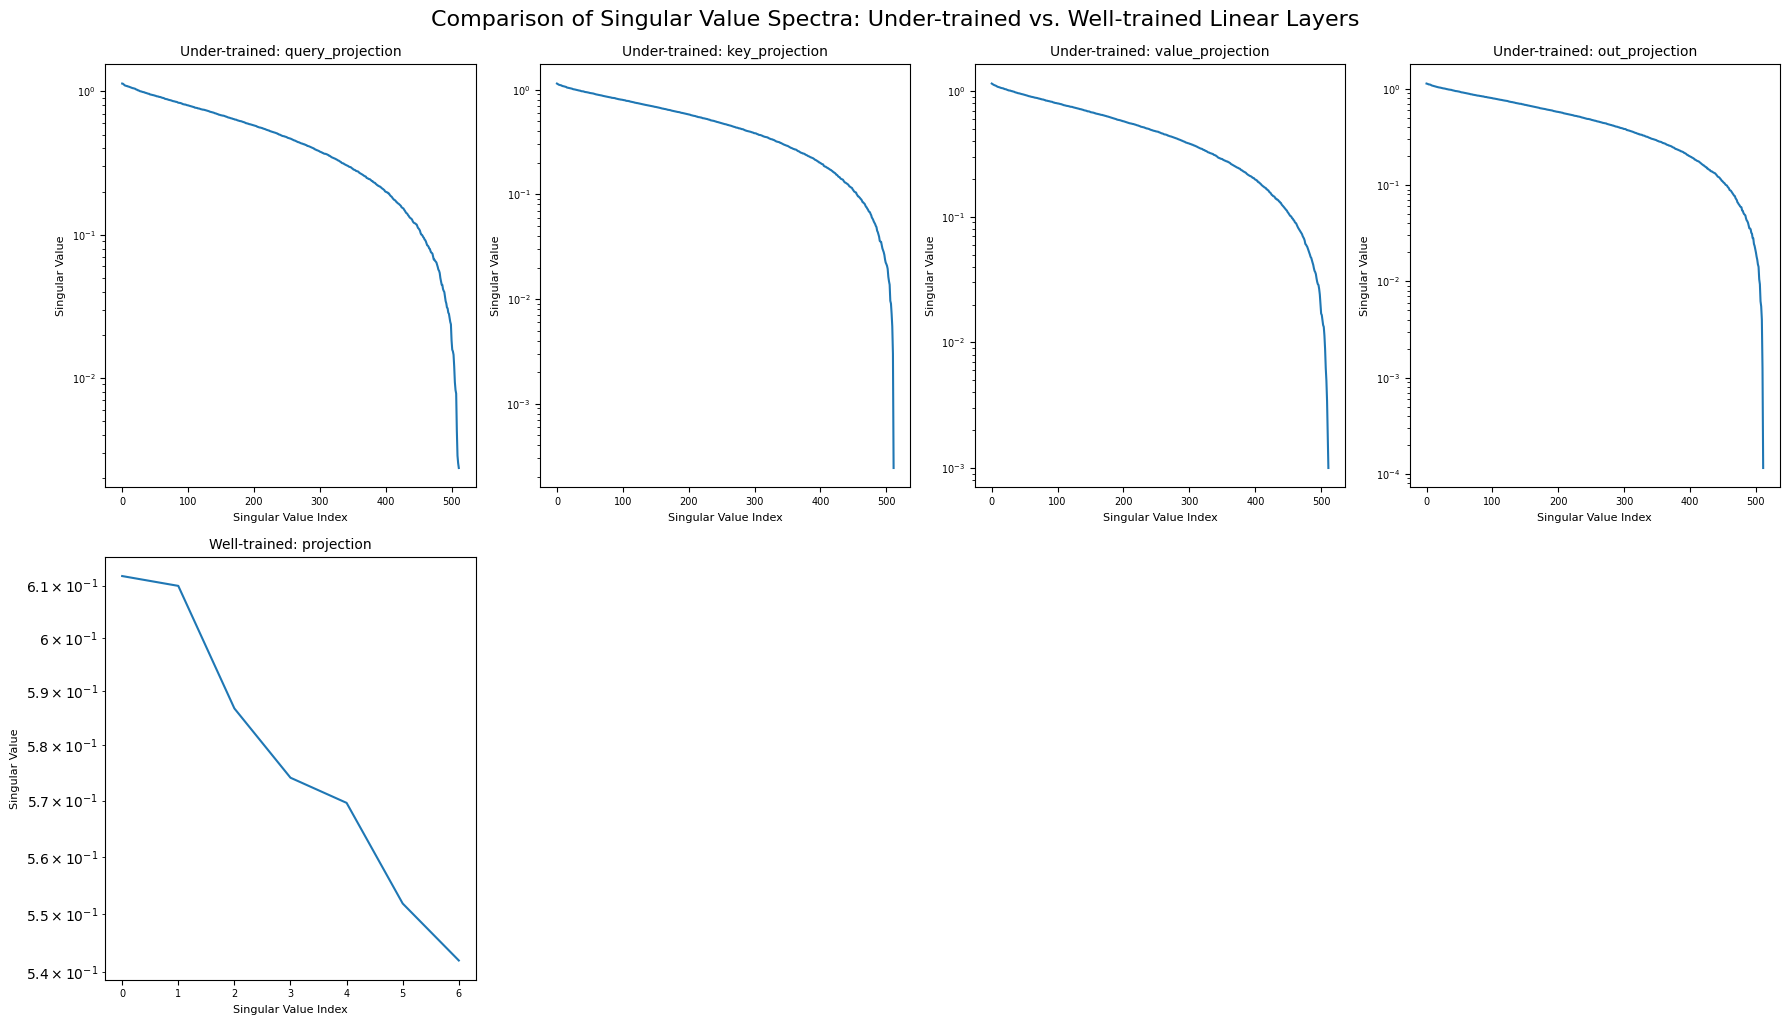

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Identify under-trained projection layers by their short names (for consistency with previous definition)
under_trained_proj_layers_short_names = [
    name for name in under_trained_layers['name'].tolist()
    if 'projection' in name and 'tokenConv' not in name
]

# Get the full names (longname) of all layers that WeightWatcher explicitly marked as 'under-trained'
all_under_trained_long_names = details_df[details_df['warning'].str.contains('under-trained', na=False)]['longname'].tolist()

# Identify all linear layers in the model by their full hierarchical name
all_linear_layers_full_names = [
    name for name, module in model.named_modules()
    if isinstance(module, torch.nn.Linear) and hasattr(module, 'weight')
]

# Select genuinely 'well-trained' linear layers:
# These are linear layers whose full name is NOT in the list of all under-trained long names.
well_trained_linear_layers = []
for layer_full_name in all_linear_layers_full_names:
    if layer_full_name not in all_under_trained_long_names:
        well_trained_linear_layers.append(layer_full_name)

# For comparison, get the full names of the under-trained projection layers for plotting
# (these were identified by their short names, now map to long names for consistency with all_layers_svs_results)
selected_under_trained_proj_layers = details_df[details_df['name'].isin(under_trained_proj_layers_short_names)]['longname'].tolist()

# Limit to a reasonable number for plotting, e.g., first 4 under-trained and first 4 well-trained linear layers
# Ensure we have enough layers to select from.
selected_under_trained_proj_layers = selected_under_trained_proj_layers[:4]
selected_well_trained_linear_layers = well_trained_linear_layers[:4]

# Update under_trained_proj_layers for subsequent use in cell 79ca73c7 (for metrics display)
# This will now contain the full names of the selected under-trained projection layers.
under_trained_proj_layers = selected_under_trained_proj_layers

print(f"Under-trained projection layers selected for comparison: {under_trained_proj_layers}")
print(f"Well-trained linear layers selected for comparison: {selected_well_trained_linear_layers}")

# Combine layers for plotting
# Use the full names for lookup in all_layers_svs_results
layers_to_plot = {
    'Under-trained': under_trained_proj_layers,
    'Well-trained': selected_well_trained_linear_layers
}

plt.figure(figsize=(18, 10))
plot_idx = 1

for category, layer_names_list in layers_to_plot.items():
    for layer_name in layer_names_list: # layer_name here is the full name now
        if layer_name in all_layers_svs_results:
            svs = all_layers_svs_results[layer_name]
            ax = plt.subplot(2, 4, plot_idx) # Adjust subplot grid as needed
            # For title, use the last part of the name for brevity in plot title
            title_name = layer_name.split('.')[-1]
            ax.plot(svs)
            ax.set_title(f'{category}: {title_name}', fontsize=10)
            ax.set_xlabel('Singular Value Index', fontsize=8)
            ax.set_ylabel('Singular Value', fontsize=8)
            ax.tick_params(axis='both', which='major', labelsize=7)
            ax.set_yscale('log') # Use log scale for singular values for better visibility of smaller values
            plot_idx += 1
        else:
            print(f"Warning: Singular values not found for layer: {layer_name}")

plt.tight_layout()
plt.suptitle('Comparison of Singular Value Spectra: Under-trained vs. Well-trained Linear Layers', y=1.02, fontsize=16)
plt.show()

#### **Distributions of Intrinsic Dimension (D) and Alpha Weighted**
This cell analyzes the metrics provided by `WeightWatcher`. It classifies layers by type (Embedding, Linear, Conv1d), filters out 'Other' types, and then calculates and prints descriptive statistics for the Intrinsic Dimension (`D`) and `alpha_weighted` for each layer type. Additionally, it generates box plots to visualize the distributions of these metrics across different layer types.

Descriptive statistics for D across layer types:
            count      mean       std       min       25%       50%       75%  \
Layer Type                                                                      
Embedding     6.0  0.169178  0.014245  0.143207  0.168096  0.170163  0.177677   
Linear       16.0  0.128972  0.006890  0.111927  0.125844  0.130286  0.133361   

                 max  
Layer Type            
Embedding   0.183946  
Linear      0.140537  

Descriptive statistics for alpha_weighted across layer types:
            count       mean       std        min        25%        50%  \
Layer Type                                                                
Embedding     6.0  15.886661  3.976743  12.076352  13.141642  14.411941   
Linear       16.0   1.191803  0.413669   0.696408   0.832659   1.104949   

                  75%        max  
Layer Type                        
Embedding   18.327277  22.069131  
Linear       1.471942   2.020753  


/tmp/ipykernel_921/3936879756.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Layer Type', y='D', data=df_metrics_filtered, palette='viridis')


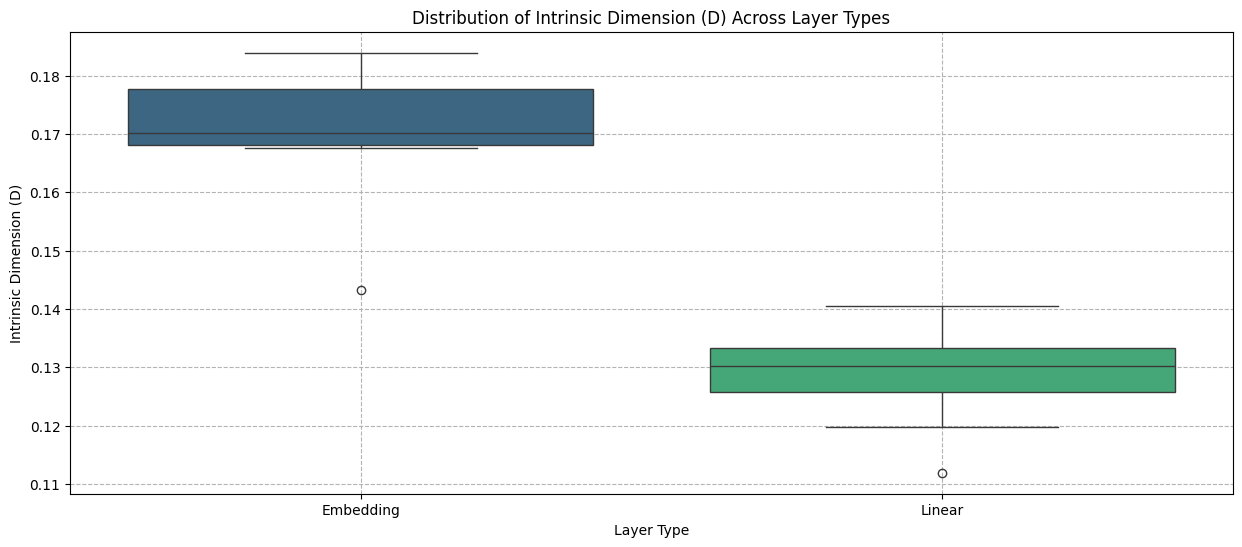

/tmp/ipykernel_921/3936879756.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Layer Type', y='alpha_weighted', data=df_metrics_filtered, palette='plasma')


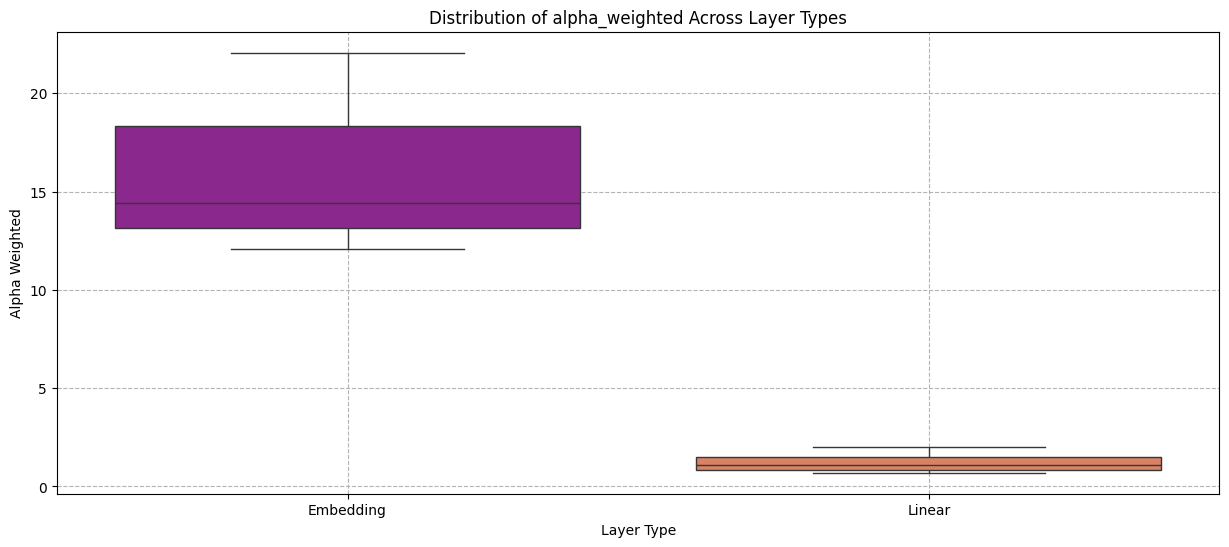

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reuse the classify_layer_type function from previous steps
def classify_layer_type(name):
    if 'query_projection' in name or 'key_projection' in name or \
       'value_projection' in name or 'out_projection' in name or \
       'projection' in name and 'tokenConv' not in name:
        return 'Linear'
    elif 'conv' in name or 'Conv' in name:
        return 'Conv1d'
    elif 'embed' in name or 'Embedding' in name:
        return 'Embedding'
    return 'Other'

# Apply the classification to the details_df DataFrame
details_df['Layer Type'] = details_df['longname'].apply(classify_layer_type)

# Filter out 'Other' types if they exist and are not useful for this analysis
df_metrics_filtered = details_df[details_df['Layer Type'] != 'Other'].copy()

print("Descriptive statistics for D across layer types:")
print(df_metrics_filtered.groupby('Layer Type')['D'].describe())

print("\nDescriptive statistics for alpha_weighted across layer types:")
print(df_metrics_filtered.groupby('Layer Type')['alpha_weighted'].describe())

# Plotting distributions for D
plt.figure(figsize=(15, 6))
sns.boxplot(x='Layer Type', y='D', data=df_metrics_filtered, palette='viridis')
plt.title('Distribution of Intrinsic Dimension (D) Across Layer Types')
plt.xlabel('Layer Type')
plt.ylabel('Intrinsic Dimension (D)')
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()

# Plotting distributions for alpha_weighted
plt.figure(figsize=(15, 6))
sns.boxplot(x='Layer Type', y='alpha_weighted', data=df_metrics_filtered, palette='plasma')
plt.title('Distribution of alpha_weighted Across Layer Types')
plt.xlabel('Layer Type')
plt.ylabel('Alpha Weighted')
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()

#### **Descriptive Statistics for sv_min and sv_max**
This cell presents the minimum (`sv_min`) and maximum (`sv_max`) singular values grouped by layer type. These statistics provide the range and scale of singular values present in different types of layers, which can be indicative of their learning behavior and stability.

In [38]:
print("Descriptive statistics for sv_min across layer types:")
print(df_metrics_filtered.groupby('Layer Type')['sv_min'].describe())

print("\nDescriptive statistics for sv_max across layer types:")
print(df_metrics_filtered.groupby('Layer Type')['sv_max'].describe())

Descriptive statistics for sv_min across layer types:
            count       mean       std        min        25%        50%  \
Layer Type                                                                
Embedding     6.0  18.481224  0.936132  17.215504  17.861576  18.463146   
Linear       16.0   0.000661  0.000582   0.000112   0.000261   0.000458   

                  75%        max  
Layer Type                        
Embedding   19.206479  19.630241  
Linear       0.000781   0.002344  

Descriptive statistics for sv_max across layer types:
            count       mean       std        min        25%        50%  \
Layer Type                                                                
Embedding     6.0  26.602076  1.237707  25.069967  25.540390  26.812042   
Linear       16.0   1.144634  0.007651   1.134146   1.140045   1.144339   

                  75%        max  
Layer Type                        
Embedding   27.694540  27.813192  
Linear       1.146756   1.165825  


#### **sv_min vs. alpha_weighted**
This cell visualizes the correlation between `sv_min` (minimum singular value) and `alpha_weighted` for different layer types. By using a scatter plot with `hue` for layer type, we can observe if there are distinct patterns or clusters for how these two metrics relate across Embedding, Conv1d, and Linear layers.

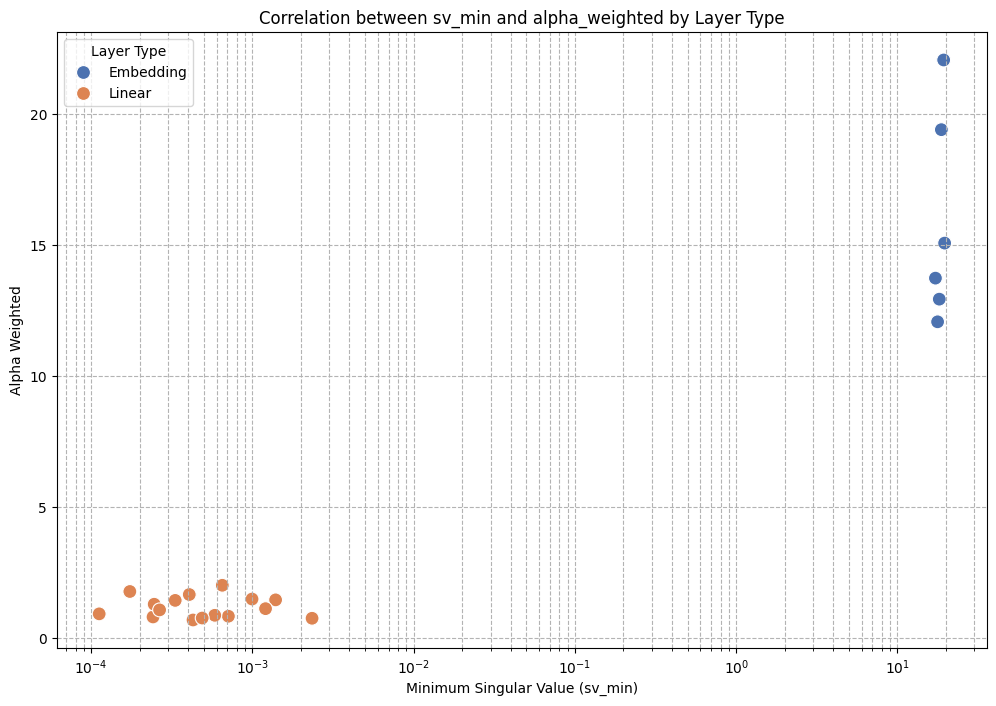

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_metrics_filtered, x='sv_min', y='alpha_weighted', hue='Layer Type', palette='deep', s=100)
plt.title('Correlation between sv_min and alpha_weighted by Layer Type')
plt.xlabel('Minimum Singular Value (sv_min)')
plt.ylabel('Alpha Weighted')
plt.xscale('log') # Use log scale for sv_min as it varies significantly
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend(title='Layer Type')
plt.show()

#### **D vs. stable_rank**
The `stable_rank` provides another perspective on the effective dimensionality of a layer. This scatter plot helps identify how Intrinsic Dimension (`D`) and `stable_rank` co-vary and if there are distinct behaviors for Embedding, Conv1d, and Linear layers.

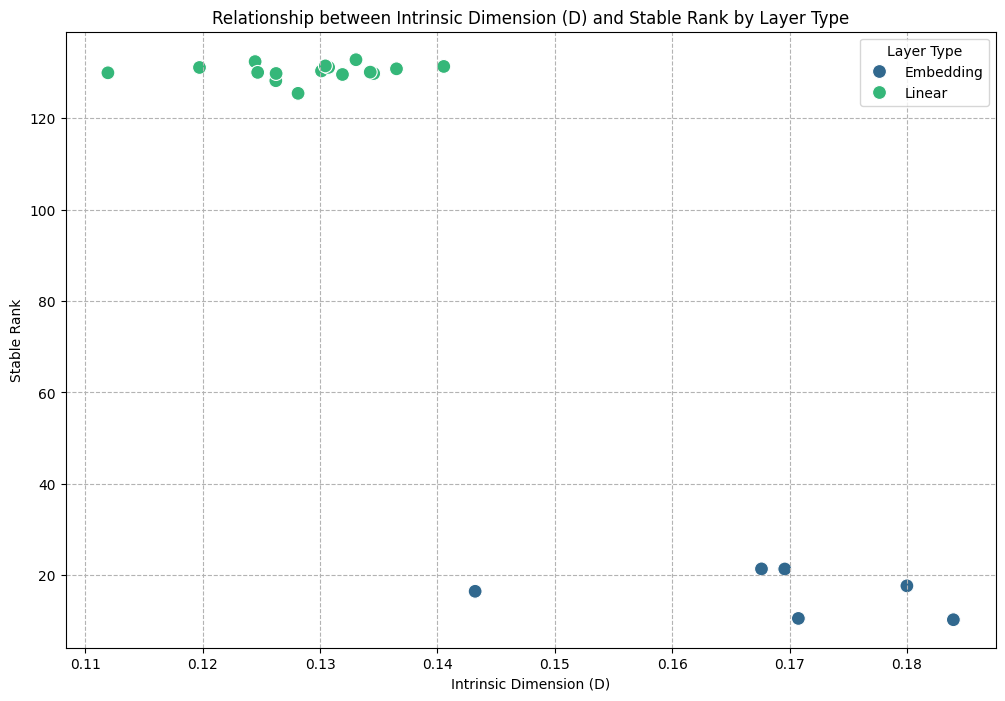

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_metrics_filtered, x='D', y='stable_rank', hue='Layer Type', palette='viridis', s=100)
plt.title('Relationship between Intrinsic Dimension (D) and Stable Rank by Layer Type')
plt.xlabel('Intrinsic Dimension (D)')
plt.ylabel('Stable Rank')
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend(title='Layer Type')
plt.show()

#### **sv_min and sv_max for Under-trained Layers**
This cell generates histograms to visualize the distributions of `sv_min` and `sv_max` specifically for the layers identified as 'under-trained'. By examining these distributions, we can understand the range and characteristics of the smallest and largest singular values in layers that `WeightWatcher` considers problematic.

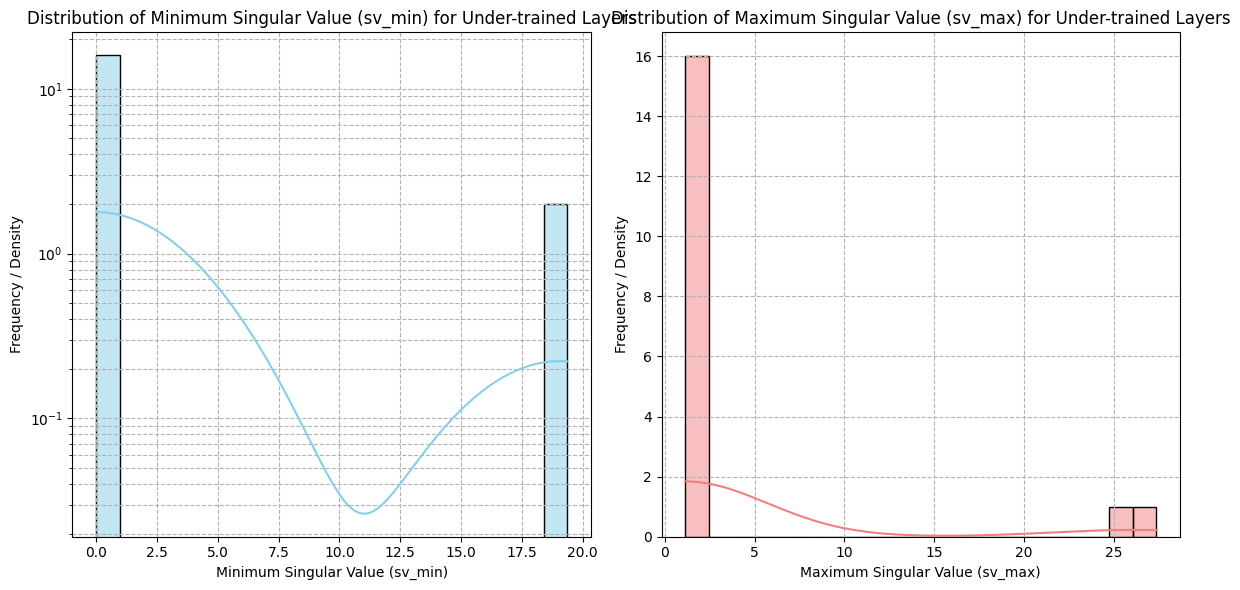

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Distribution of sv_min for Under-trained Layers
plt.subplot(1, 2, 1)
sns.histplot(data=under_trained_layers, x='sv_min', kde=True, bins=20, color='skyblue')
plt.title('Distribution of Minimum Singular Value (sv_min) for Under-trained Layers')
plt.xlabel('Minimum Singular Value (sv_min)')
plt.ylabel('Frequency / Density')
plt.yscale('log') # Use log scale for frequency to better visualize spread
plt.grid(True, which="both", ls="--", c='0.7')

# Distribution of sv_max for Under-trained Layers
plt.subplot(1, 2, 2)
sns.histplot(data=under_trained_layers, x='sv_max', kde=True, bins=20, color='lightcoral')
plt.title('Distribution of Maximum Singular Value (sv_max) for Under-trained Layers')
plt.xlabel('Maximum Singular Value (sv_max)')
plt.ylabel('Frequency / Density')
plt.grid(True, which="both", ls="--", c='0.7')

plt.tight_layout()
plt.show()

#### **Correlation Heatmap of Layer Metrics**
Finally, this notebook visualizes a correlation heatmap of layer metrics provided by `WeightWatcher` (`D`, `alpha`, `alpha_weighted`, `entropy`, `sigma`, `spectral_norm`, `stable_rank`, `sv_max`, `sv_min`). This heatmap helps in identifying strong positive or negative relationships between these different indicators, providing a overview of how these characteristics interplay within the model's layers.

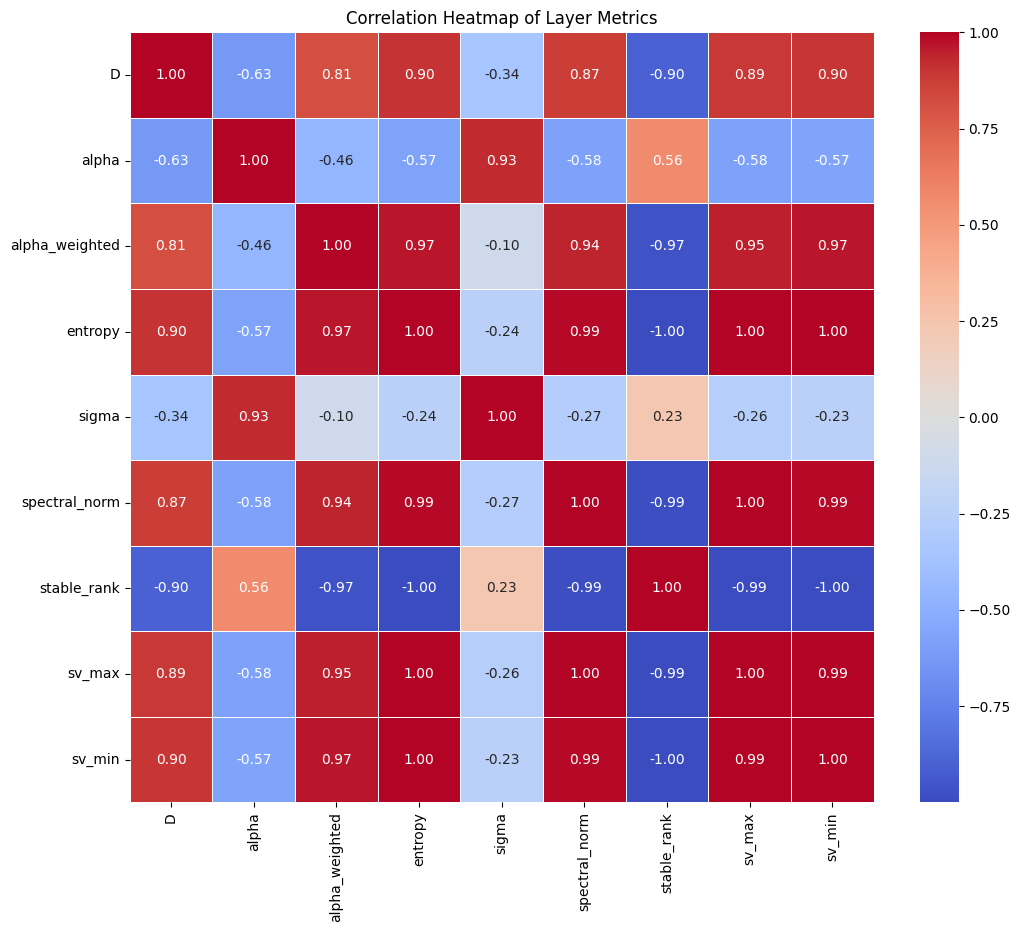

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Excluding 'layer_id' and other non-numerical or redundant columns
correlation_metrics = df_metrics_filtered[['D', 'alpha', 'alpha_weighted', 'entropy', 'sigma',
                                           'spectral_norm', 'stable_rank', 'sv_max', 'sv_min']].copy()

correlation_matrix = correlation_metrics.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Layer Metrics')
plt.show()